# Exploración y Análisis de Datos

**Objetivo:** Realizar una exploración general de los datos financieros con los que se trabaja 
en el proyecto, verificando su integridad, distribución y características principales antes 
de proceder al entrenamiento de modelos.

**Datos:** Precios de cierre diarios de 23 activos del S&P 500 y sus log-returns.

In [1]:
import sys
import os

# Buscar el directorio raíz del proyecto localizando config.py
def find_project_root():
    path = os.getcwd()
    for _ in range(5):
        if os.path.exists(os.path.join(path, 'config.py')):
            return path
        path = os.path.dirname(path)
    return None

project_root = find_project_root()
if project_root:
    os.chdir(project_root)
    sys.path.insert(0, project_root)
    print(f"Directorio de trabajo: {os.getcwd()}")
else:
    print("ERROR: No se encontró el directorio raíz del proyecto")

Directorio de trabajo: /Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Redes Neuronales para Forecasting/neural-network-forecasting


## 1. Imports y configuración

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from config import TICKERS, START_DATE, END_DATE

print(f"Tickers: {len(TICKERS)} activos")
print(f"Periodo: {START_DATE} → {END_DATE}")

Tickers: 23 activos
Periodo: 1945-01-01 → 2026-05-05


## 2. Carga de datos brutos

Se descargan los precios de cierre diarios de los 23 activos para analizar 
los datos en su forma original antes de cualquier transformación.

In [3]:
# Descarga de precios de cierre
precios_close = yf.download(
    TICKERS,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=True
)['Close']

print(f"\nShape original: {precios_close.shape}")
print(f"Rango temporal: {precios_close.index[0].strftime('%Y-%m-%d')} → {precios_close.index[-1].strftime('%Y-%m-%d')}")
print(f"Activos: {list(precios_close.columns)}")

[*********************100%***********************]  23 of 23 completed


Shape original: (16192, 23)
Rango temporal: 1962-01-02 → 2026-05-04
Activos: ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']


## 3. Análisis de datos faltantes

Se verifica la presencia de valores nulos en los precios de cierre para determinar 
si es necesario algún tratamiento de datos faltantes.

In [4]:
# Conteo de valores nulos por activo
nulos_por_activo = precios_close.isnull().sum()
nulos_pct = (precios_close.isnull().sum() / len(precios_close) * 100)

print("Valores nulos por activo:")
print("=" * 50)
for ticker in TICKERS:
    n = nulos_por_activo[ticker]
    pct = nulos_pct[ticker]
    print(f"  {ticker:<6} {n:>6} nulos ({pct:>5.2f}%)")

print(f"\nTotal filas: {len(precios_close)}")
print(f"Filas completas (sin ningún nulo): {precios_close.dropna().shape[0]}")
print(f"Filas con al menos un nulo: {precios_close.isnull().any(axis=1).sum()}")

Valores nulos por activo:
  AEP         0 nulos ( 0.00%)
  BA          0 nulos ( 0.00%)
  CAT         0 nulos ( 0.00%)
  CNP         0 nulos ( 0.00%)
  CVX         0 nulos ( 0.00%)
  DIS         0 nulos ( 0.00%)
  DTE         0 nulos ( 0.00%)
  ED          0 nulos ( 0.00%)
  GD          0 nulos ( 0.00%)
  GE          0 nulos ( 0.00%)
  HON         0 nulos ( 0.00%)
  HPQ         0 nulos ( 0.00%)
  IBM         0 nulos ( 0.00%)
  IP          0 nulos ( 0.00%)
  JNJ         0 nulos ( 0.00%)
  KO          0 nulos ( 0.00%)
  KR          0 nulos ( 0.00%)
  MMM         0 nulos ( 0.00%)
  MO          0 nulos ( 0.00%)
  MRK         0 nulos ( 0.00%)
  MSI         0 nulos ( 0.00%)
  PG          0 nulos ( 0.00%)
  XOM         0 nulos ( 0.00%)

Total filas: 16192
Filas completas (sin ningún nulo): 16192
Filas con al menos un nulo: 0


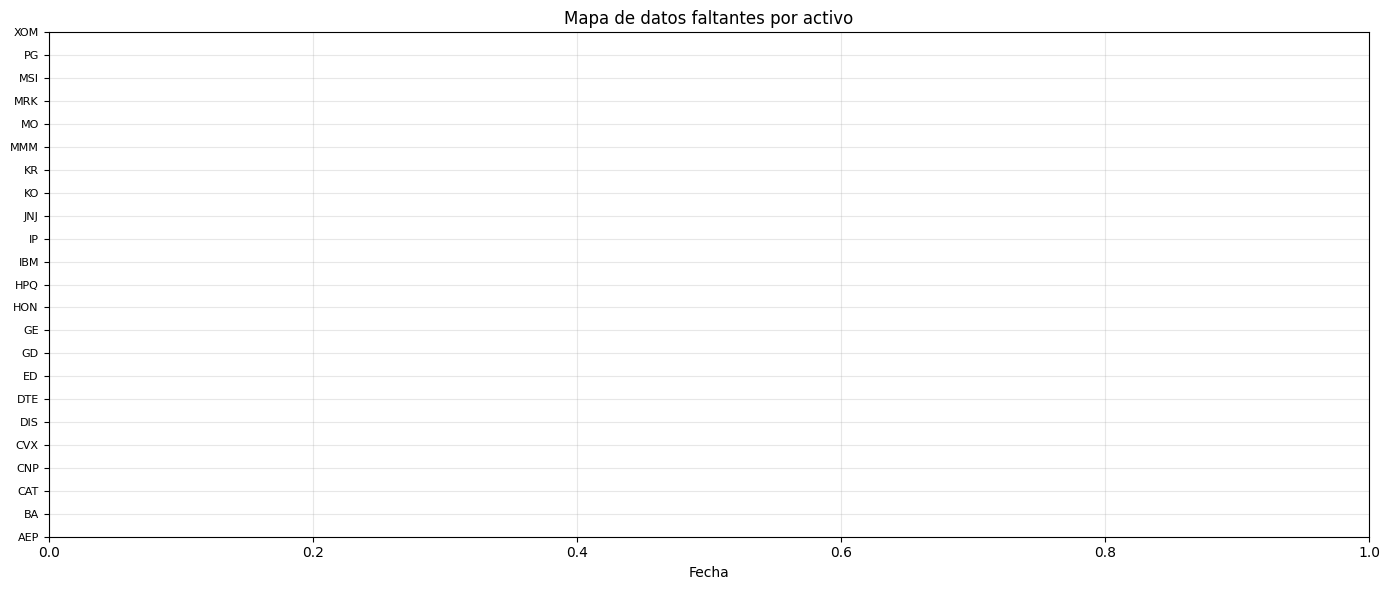

In [5]:
# Visualización de datos faltantes
fig, ax = plt.subplots(figsize=(14, 6))

for i, ticker in enumerate(TICKERS):
    missing = precios_close[ticker].isnull()
    if missing.any():
        missing_dates = precios_close.index[missing]
        ax.scatter(missing_dates, [i] * len(missing_dates), s=1, c='red', alpha=0.5)

ax.set_yticks(range(len(TICKERS)))
ax.set_yticklabels(TICKERS, fontsize=8)
ax.set_xlabel('Fecha')
ax.set_title('Mapa de datos faltantes por activo')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Tratamiento de datos faltantes

Se eliminan las columnas que contengan valores nulos completos y se procede 
al cálculo de log-returns, eliminando la primera fila resultante del cálculo 
diferencial.

In [6]:
# Eliminar columnas con nulos
precios_clean = precios_close.dropna(axis=1)
print(f"Activos tras limpieza: {precios_clean.shape[1]} de {precios_close.shape[1]}")

if precios_clean.shape[1] < precios_close.shape[1]:
    eliminados = set(precios_close.columns) - set(precios_clean.columns)
    print(f"Activos eliminados: {eliminados}")
else:
    print("No se ha eliminado ningún activo")

# Cálculo de log-returns
returns = np.log(precios_clean).diff().dropna()

print(f"\nLog-returns shape: {returns.shape}")
print(f"Rango: {returns.index[0].strftime('%Y-%m-%d')} → {returns.index[-1].strftime('%Y-%m-%d')}")
print(f"Valores nulos en log-returns: {returns.isnull().sum().sum()}")

Activos tras limpieza: 23 de 23
No se ha eliminado ningún activo

Log-returns shape: (16191, 23)
Rango: 1962-01-03 → 2026-05-04
Valores nulos en log-returns: 0


## 5. Estadísticas descriptivas de los log-returns

In [7]:
# Estadísticas generales
stats = returns.describe().T
stats['skewness'] = returns.skew()
stats['kurtosis'] = returns.kurtosis()

print("Estadísticas descriptivas de los log-returns diarios:")
print("=" * 90)
print(stats[['mean', 'std', 'min', 'max', 'skewness', 'kurtosis']].to_string())

Estadísticas descriptivas de los log-returns diarios:
            mean       std       min       max  skewness    kurtosis
Ticker                                                              
AEP     0.000310  0.013076 -0.258574  0.181002 -0.234897   19.899369
BA      0.000436  0.021387 -0.272444  0.217677 -0.038853    9.205318
CAT     0.000466  0.018671 -0.243622  0.137350 -0.238639    6.382721
CNP     0.000310  0.017253 -0.548341  0.488353 -1.665147  130.695132
CVX     0.000398  0.016139 -0.250062  0.204904 -0.284523   12.943470
DIS     0.000462  0.019818 -0.343821  0.174755 -0.381235   12.300522
DTE     0.000367  0.012494 -0.149719  0.145182 -0.067441   11.955399
ED      0.000378  0.012591 -0.384845  0.165632 -2.200124   72.966824
GD      0.000472  0.018858 -0.156282  0.182321  0.158420    5.485081
GE      0.000378  0.017368 -0.192223  0.179844 -0.113407    8.266320
HON     0.000332  0.018190 -0.348040  0.271718 -0.270302   19.925326
HPQ     0.000388  0.022594 -0.226812  0.159465 -0

In [8]:
# Resumen global
print("\nResumen global de los log-returns:")
print("=" * 50)
print(f"Media global:              {returns.values.mean():.6f}")
print(f"Desviación estándar global:{returns.values.std():.6f}")
print(f"Mínimo global:             {returns.values.min():.6f}")
print(f"Máximo global:             {returns.values.max():.6f}")
print(f"Mediana global:            {np.median(returns.values):.6f}")


Resumen global de los log-returns:
Media global:              0.000408
Desviación estándar global:0.017137
Mínimo global:             -0.548341
Máximo global:             0.488353
Mediana global:            0.000000


## 6. Distribución de los log-returns

Se analiza la distribución de los log-returns para verificar las características 
típicas de datos financieros: media cercana a cero, colas pesadas y exceso de curtosis.

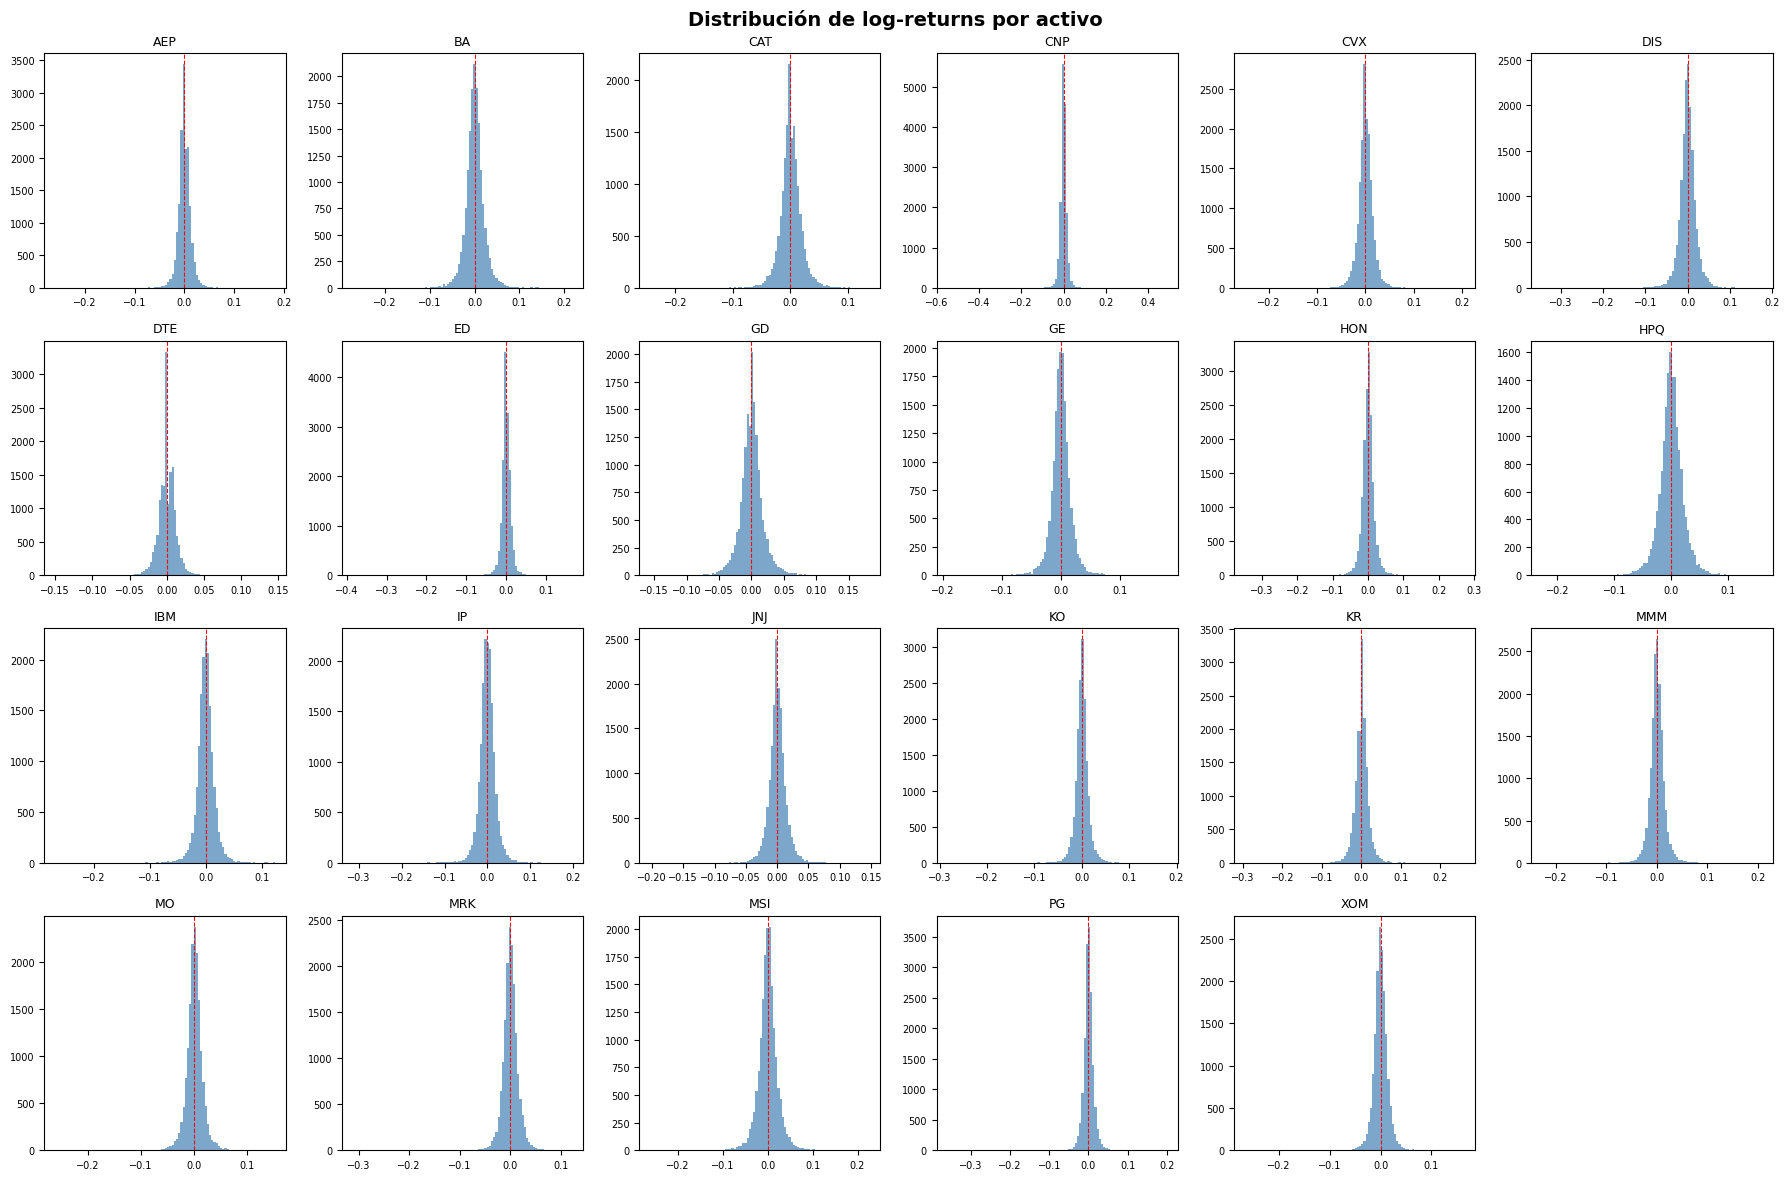

In [9]:
fig, axes = plt.subplots(4, 6, figsize=(18, 12))
fig.suptitle('Distribución de log-returns por activo', fontsize=14, fontweight='bold')

for idx, (ticker, ax) in enumerate(zip(TICKERS, axes.flat)):
    ax.hist(returns[ticker], bins=100, color='steelblue', alpha=0.7, edgecolor='none')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=0.8)
    ax.set_title(ticker, fontsize=9)
    ax.tick_params(labelsize=7)

# Ocultar ejes sobrantes si hay menos de 24 activos
for idx in range(len(TICKERS), len(axes.flat)):
    axes.flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

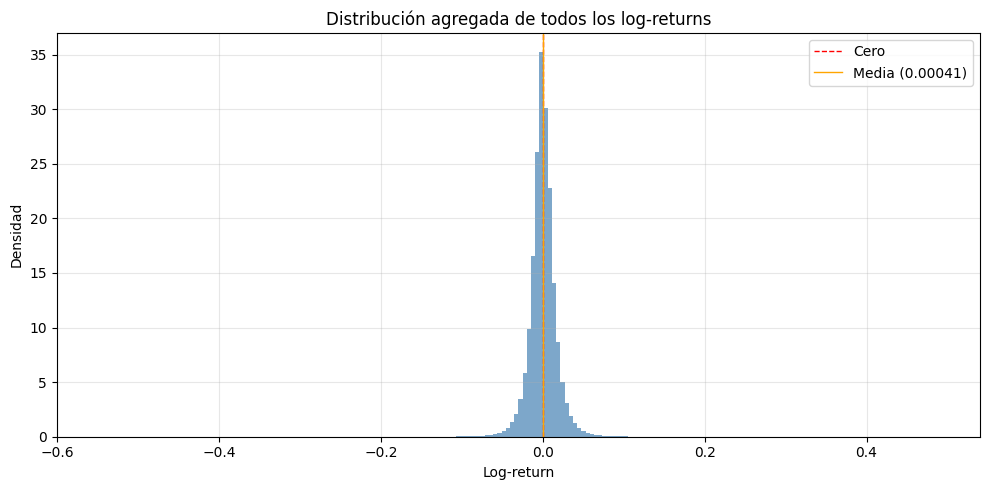

In [10]:
# Distribución agregada de todos los log-returns
fig, ax = plt.subplots(figsize=(10, 5))

all_returns = returns.values.flatten()
ax.hist(all_returns, bins=200, color='steelblue', alpha=0.7, edgecolor='none', density=True)
ax.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Cero')
ax.axvline(x=all_returns.mean(), color='orange', linestyle='-', linewidth=1, label=f'Media ({all_returns.mean():.5f})')
ax.set_title('Distribución agregada de todos los log-returns')
ax.set_xlabel('Log-return')
ax.set_ylabel('Densidad')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Evolución temporal de los precios

Visualización de la evolución de los precios de cierre normalizados (base 100) 
para observar tendencias y periodos de alta/baja volatilidad.

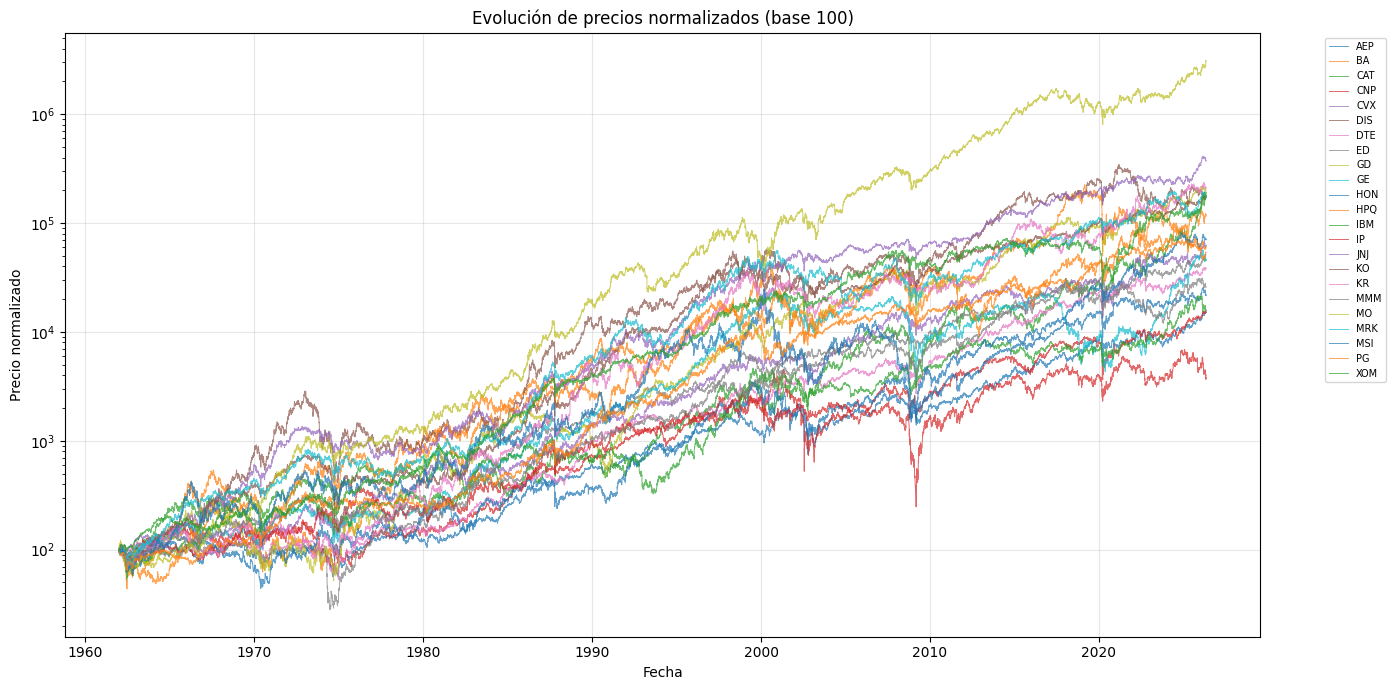

In [11]:
# Precios normalizados (base 100)
precios_norm = precios_clean / precios_clean.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 7))

for ticker in TICKERS:
    ax.plot(precios_norm[ticker], linewidth=0.7, alpha=0.7, label=ticker)

ax.set_title('Evolución de precios normalizados (base 100)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio normalizado')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 8. Análisis de volatilidad

Se calcula la volatilidad móvil (desviación estándar de los log-returns en ventanas 
de 60 días) para identificar periodos de alta y baja volatilidad en el mercado.

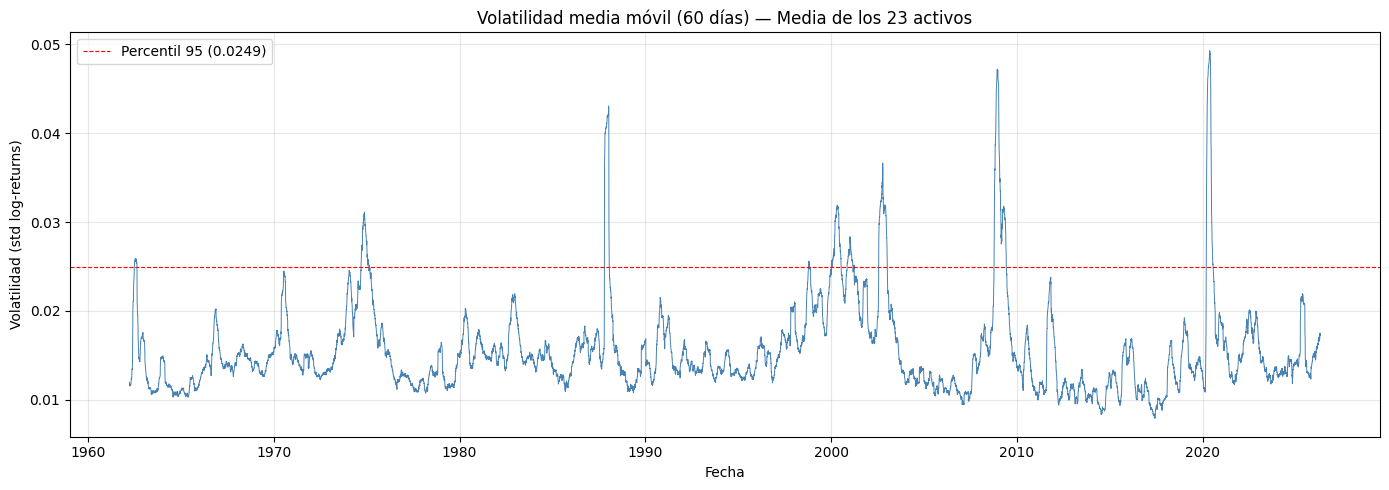

Volatilidad media global: 0.015504
Percentil 95: 0.024937
Días por encima del P95: 807


In [12]:
# Volatilidad móvil (60 días)
vol_rolling = returns.rolling(window=60).std()

# Volatilidad media de todos los activos
vol_media = vol_rolling.mean(axis=1)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(vol_media.index, vol_media.values, linewidth=0.7, color='steelblue')
ax.set_title('Volatilidad media móvil (60 días) — Media de los 23 activos')
ax.set_xlabel('Fecha')
ax.set_ylabel('Volatilidad (std log-returns)')
ax.grid(True, alpha=0.3)

# Marcar periodos de alta volatilidad
vol_threshold = vol_media.quantile(0.95)
high_vol = vol_media[vol_media > vol_threshold]
ax.axhline(y=vol_threshold, color='red', linestyle='--', linewidth=0.8, 
           label=f'Percentil 95 ({vol_threshold:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Volatilidad media global: {vol_media.mean():.6f}")
print(f"Percentil 95: {vol_threshold:.6f}")
print(f"Días por encima del P95: {len(high_vol)}")

## 9. Matriz de correlación

Se analiza la correlación entre los log-returns de los 23 activos para identificar 
dependencias y agrupaciones entre ellos.

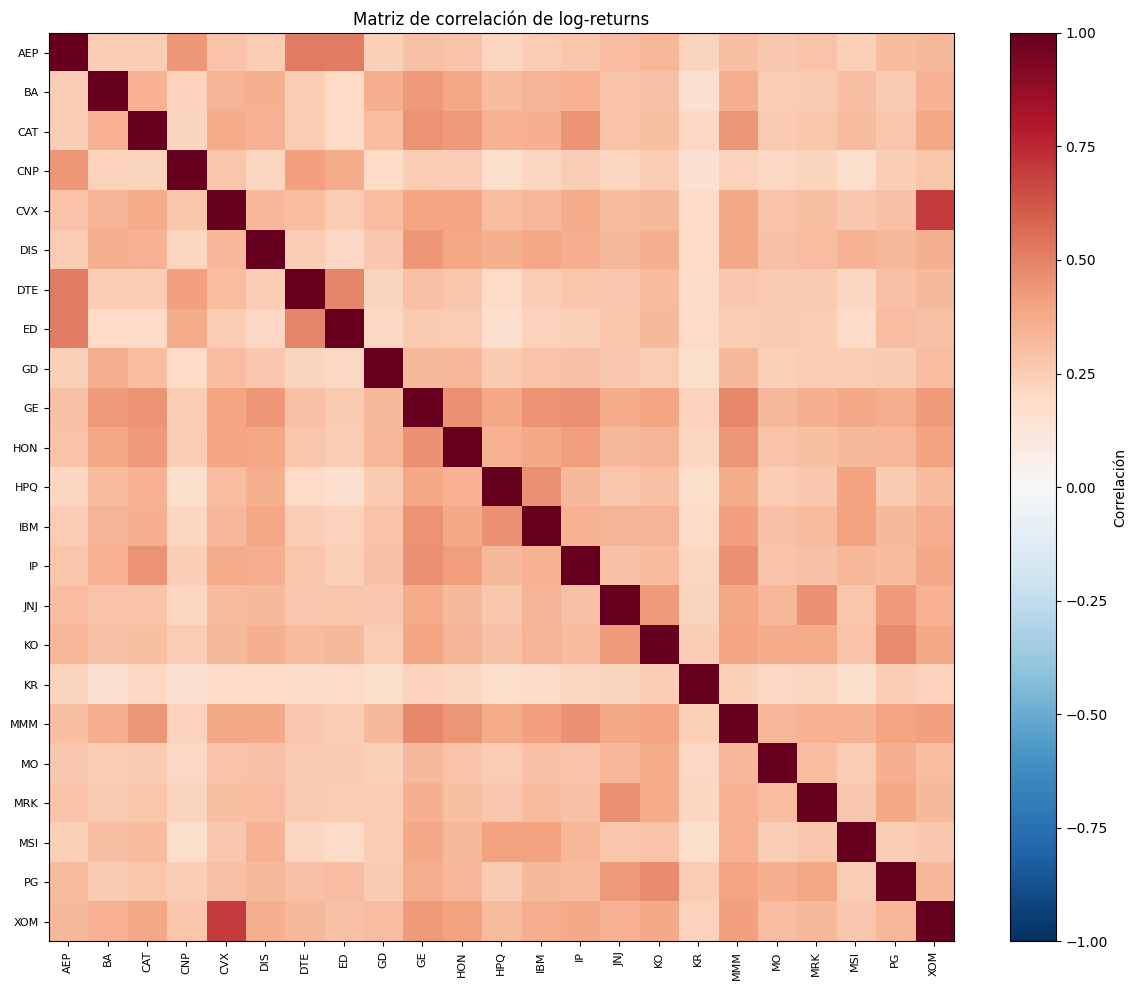

Correlación media entre activos: 0.3088
Correlación máxima: 0.7028 (('CVX', 'XOM'))
Correlación mínima: 0.1519 (('CNP', 'KR'))


In [13]:
# Matriz de correlación
corr_matrix = returns.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(TICKERS)))
ax.set_xticklabels(TICKERS, rotation=90, fontsize=8)
ax.set_yticks(range(len(TICKERS)))
ax.set_yticklabels(TICKERS, fontsize=8)
ax.set_title('Matriz de correlación de log-returns')

plt.colorbar(im, ax=ax, label='Correlación')
plt.tight_layout()
plt.show()

# Estadísticas de correlación
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
correlations = upper_triangle.stack()

print(f"Correlación media entre activos: {correlations.mean():.4f}")
print(f"Correlación máxima: {correlations.max():.4f} ({correlations.idxmax()})")
print(f"Correlación mínima: {correlations.min():.4f} ({correlations.idxmin()})")

## 10. Análisis del target — Efecto de la ventana de salida

Se analiza cómo cambia la distribución del target (promedio de log-returns futuros) 
en función del tamaño de la ventana de salida. Esto es relevante porque el MAE 
depende directamente de la magnitud de los valores a predecir.

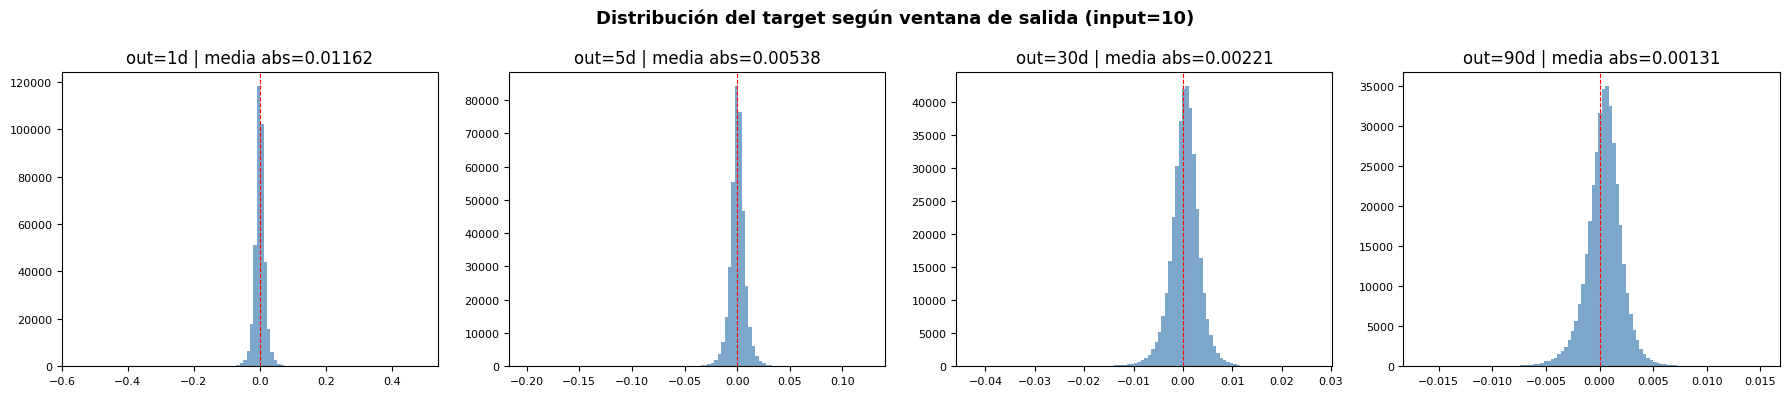

Media absoluta del target por ventana de salida:
  out= 1d → media |y| = 0.011618
  out= 5d → media |y| = 0.005377
  out=30d → media |y| = 0.002213
  out=90d → media |y| = 0.001305


In [14]:
from src.data_pipeline import create_time_series_data

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Distribución del target según ventana de salida (input=10)', fontsize=13, fontweight='bold')

output_windows = [1, 5, 30, 90]

for ow, ax in zip(output_windows, axes):
    _, y = create_time_series_data(returns, 10, ow)
    y_flat = y.flatten()
    ax.hist(y_flat, bins=100, color='steelblue', alpha=0.7, edgecolor='none')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=0.8)
    ax.set_title(f'out={ow}d | media abs={np.mean(np.abs(y_flat)):.5f}')
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

print("Media absoluta del target por ventana de salida:")
print("=" * 45)
for ow in output_windows:
    _, y = create_time_series_data(returns, 10, ow)
    print(f"  out={ow:>2}d → media |y| = {np.mean(np.abs(y)):.6f}")